<div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 40px; margin-top: 0;">
    <div style="flex: 0 0 auto; margin-left: 0; margin-bottom: 0; margin-top: 0;">
        <img src="./pics/UCSD Logo.png" alt="UCSD Logo" style="width: 179px; margin-bottom: 0px; margin-top: 20px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/sdsc-logo.png" alt="SDSC Logo" style="width: 300px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/usgs-logo.png" alt="USGS Logo" style="width: 100px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/wstc-logo.png" alt="WSTC Logo" style="width: 100px; height: 100px; margin-bottom: 0px;">
    </div>
</div>

<h1 style="text-align: center; font-size: 48px; margin-top: 0;">3D Elevation Program (3DEP)</h1>

- **Team Name:**   SAMI BAHIG
- **Team Members:**
    SAMI BAHIG

1. In the `3DEP.ipynb` notebook, we previously selected a random image in California. 

For this Data Challenge, you will work with data located from [D. L. Bliss State Park](https://en.wikipedia.org/wiki/D._L._Bliss_State_Park), one of our areas of interest (AOI). Use 3DEP data in Google Earth Engine to identify and select a 3DEP image within D. L. Bliss.

Use coordinates within the following bounding box (WGS84 lon/lat):

* Min X (lon): -120.1018846
* Min Y (lat): 38.99274873
* Max X (lon): -120.0899834
* Max Y (lat): 39.0020357

In [1]:
# Your code here
import ee
import geemap
import folium
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ee.Authenticate()
ee.Initialize(project='ee-samibahig')

In [3]:
# Load 3DEP collection
threedep_10m = ee.ImageCollection('USGS/3DEP/10m_collection')

# Define AOI for D.L. Bliss
aoi = ee.Geometry.Rectangle(
    [-120.1018846, 38.99274873, -120.0899834, 39.0020357],
    geodesic=False
)

# Select elevation band and filter by AOI
elevation = threedep_10m.select('elevation')
elev_img = elevation.filterBounds(aoi).first()

# Print properties
props = elev_img.getInfo()
print("Image ID:", elev_img.id().getInfo())
print("Scale (m):", elev_img.projection().nominalScale().getInfo())
print("Projection:", elev_img.projection().getInfo())
print("Bands:", elev_img.bandNames().getInfo())

Image ID: USGS_13_n39w121
Scale (m): 10.3073602743545
Projection: {'type': 'Projection', 'crs': 'EPSG:4269', 'transform': [9.259259269220167e-05, 0, -121.00055555619338, 0, -9.259259277537894e-05, 39.00055555659456]}
Bands: ['elevation']


In [4]:
slope_img  = ee.Terrain.slope(elev_img).rename("slope")
aspect_img = ee.Terrain.aspect(elev_img).rename("aspect")

print("Slope band:", slope_img.bandNames().getInfo())
print("Aspect band:", aspect_img.bandNames().getInfo())

Slope band: ['slope']
Aspect band: ['aspect']


In [6]:
# Build 4.5km x 4.5km ROI anchored at SW corner of AOI
km   = 4.5
dlat = km / 111.32
dlon = km / (111.32 * np.cos(np.deg2rad(38.99274873)))

sw_lon, sw_lat = -120.1018846, 38.99274873

roi = ee.Geometry.Rectangle(
    [sw_lon, sw_lat, sw_lon + dlon, sw_lat + dlat],
    geodesic=False
)

FILL = -9999.0

def sample_band_to_numpy(img, band_name, region, fill_value=FILL, dtype=np.float32):
    rect = img.toFloat().sampleRectangle(region=region, defaultValue=fill_value)
    arr  = np.array(rect.get(band_name).getInfo(), dtype=dtype)
    arr[arr == fill_value] = np.nan
    return arr

elev_arr   = sample_band_to_numpy(elev_img,   "elevation", roi)
slope_arr  = sample_band_to_numpy(slope_img,  "slope",     roi)
aspect_arr = sample_band_to_numpy(aspect_img, "aspect",    roi)

print("elev  :", elev_arr.shape,   "min/max:", np.nanmin(elev_arr),   np.nanmax(elev_arr))
print("slope :", slope_arr.shape,  "min/max:", np.nanmin(slope_arr),  np.nanmax(slope_arr))
print("aspect:", aspect_arr.shape, "min/max:", np.nanmin(aspect_arr), np.nanmax(aspect_arr))

elev  : (438, 563) min/max: 1897.4237 2068.8293
slope : (438, 563) min/max: 0.0 66.89961
aspect: (438, 563) min/max: 0.0 359.98904


2. Using the DL Bliss image, visualize the elevation, slope and aspect

In [8]:
# Your code here
# Clip to AOI buffer
roi_viz = aoi.buffer(5000).bounds()
elev_clip   = elev_img.clip(roi_viz)
slope_clip  = slope_img.clip(roi_viz)
aspect_clip = aspect_img.clip(roi_viz)

# Visualization params
elev_vis = {
    "min": 0, "max": 3000,
    "palette": ["0000ff", "00ffff", "00ff00", "ffff00", "ff0000", "ffffff"]
}
slope_vis = {
    "min": 0, "max": 90,
    "palette": ["ffffff", "fff7bc", "fec44f", "fe9929", "ec7014", "cc4c02", "8c2d04"]
}
aspect_vis = {
    "min": 0, "max": 360,
    "palette": ["ff0000", "ffff00", "00ff00", "00ffff", "0000ff", "ff00ff", "ff0000"]
}

# Helper function
def add_ee_layer(m, ee_img, vis_params, name):
    map_dict = ee_img.getMapId(vis_params)
    folium.TileLayer(
        tiles=map_dict["tile_fetcher"].url_format,
        attr="Google Earth Engine",
        overlay=True,
        name=name,
    ).add_to(m)

# Centre on D.L. Bliss
centre_lat = (38.99274873 + 39.0020357) / 2
centre_lon = (-120.1018846 + -120.0899834) / 2

m = folium.Map(location=[centre_lat, centre_lon], zoom_start=13)

add_ee_layer(m, elev_clip,   elev_vis,   "3DEP Elevation (m)")
add_ee_layer(m, slope_clip,  slope_vis,  "Slope (deg)")
add_ee_layer(m, aspect_clip, aspect_vis, "Aspect (deg)")

# AOI rectangle
folium.Rectangle(
    bounds=[[38.99274873, -120.1018846], [39.0020357, -120.0899834]],
    color='red', fill=False, weight=2, tooltip='D.L. Bliss AOI'
).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m

3. Compute and plot a histogram and basic summary statistics (mean, median, min, max) for the elevation of your selected image.

In [9]:
# Your code here
# Build 4.5km x 4.5km ROI anchored at SW corner of AOI
km   = 4.5
dlat = km / 111.32
dlon = km / (111.32 * np.cos(np.deg2rad(38.99274873)))

sw_lon, sw_lat = -120.1018846, 38.99274873

roi = ee.Geometry.Rectangle(
    [sw_lon, sw_lat, sw_lon + dlon, sw_lat + dlat],
    geodesic=False
)

FILL = -9999.0

def sample_band_to_numpy(img, band_name, region, fill_value=FILL, dtype=np.float32):
    rect = img.toFloat().sampleRectangle(region=region, defaultValue=fill_value)
    arr  = np.array(rect.get(band_name).getInfo(), dtype=dtype)
    arr[arr == fill_value] = np.nan
    return arr

elev_arr   = sample_band_to_numpy(elev_img,   "elevation", roi)
slope_arr  = sample_band_to_numpy(slope_img,  "slope",     roi)
aspect_arr = sample_band_to_numpy(aspect_img, "aspect",    roi)

print("elev  :", elev_arr.shape,   "min/max:", np.nanmin(elev_arr),   np.nanmax(elev_arr))
print("slope :", slope_arr.shape,  "min/max:", np.nanmin(slope_arr),  np.nanmax(slope_arr))
print("aspect:", aspect_arr.shape, "min/max:", np.nanmin(aspect_arr), np.nanmax(aspect_arr))

elev  : (438, 563) min/max: 1897.4237 2068.8293
slope : (438, 563) min/max: 0.0 66.89961
aspect: (438, 563) min/max: 0.0 359.98904


=== Elevation Summary Statistics — D.L. Bliss ===
  Mean   : 1907.39 m
  Median : 1897.55 m
  Min    : 1897.42 m
  Max    : 2068.83 m
  Valid pixels : 47,855


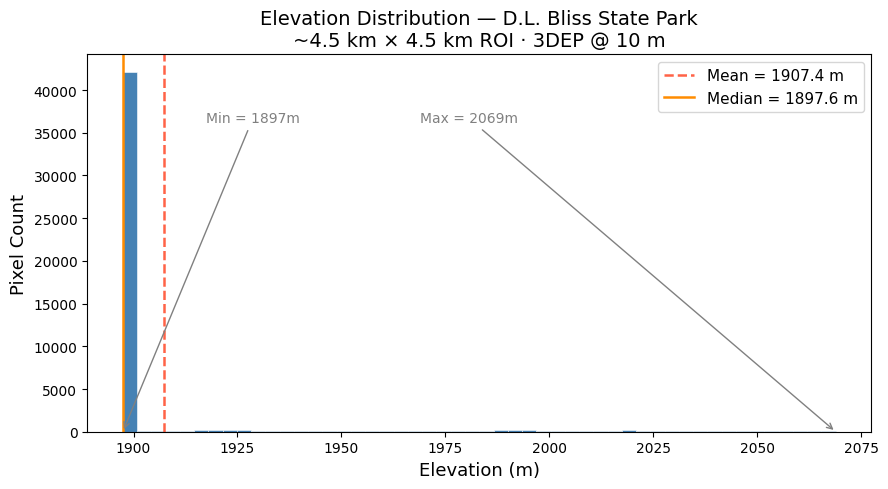

In [10]:
valid = elev_arr[~np.isnan(elev_arr)]

mean_v   = np.mean(valid)
median_v = np.median(valid)
min_v    = np.min(valid)
max_v    = np.max(valid)

print("=== Elevation Summary Statistics — D.L. Bliss ===")
print(f"  Mean   : {mean_v:.2f} m")
print(f"  Median : {median_v:.2f} m")
print(f"  Min    : {min_v:.2f} m")
print(f"  Max    : {max_v:.2f} m")
print(f"  Valid pixels : {len(valid):,}")

# Histogram
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(valid, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(mean_v,   color='tomato',     linestyle='--', linewidth=1.8,
           label=f'Mean = {mean_v:.1f} m')
ax.axvline(median_v, color='darkorange', linestyle='-',  linewidth=1.8,
           label=f'Median = {median_v:.1f} m')

ax.set_xlabel('Elevation (m)', fontsize=13)
ax.set_ylabel('Pixel Count',   fontsize=13)
ax.set_title(
    'Elevation Distribution — D.L. Bliss State Park\n'
    '~4.5 km × 4.5 km ROI · 3DEP @ 10 m',
    fontsize=14
)
ax.legend(fontsize=11)

ymax = ax.get_ylim()[1]
ax.annotate(f'Min = {min_v:.0f}m', xy=(min_v, 0),
            xytext=(min_v + 20, ymax * 0.82),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='gray')
ax.annotate(f'Max = {max_v:.0f}m', xy=(max_v, 0),
            xytext=(max_v - 100, ymax * 0.82),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='gray')

plt.tight_layout()
plt.show()

## Interpretation

**Q1 — Image Selection:**
The 3DEP image intersecting D.L. Bliss State Park was identified using 
`filterBounds()` on the AOI bounding box, consistent with the approach used 
for RAP tile selection in Sprint 1.

**Q2 — Visualization:**
The three layers (elevation, slope, aspect) provide complementary terrain 
information for D.L. Bliss. The elevation layer shows the topographic 
relief of the Sierra Nevada, the slope layer highlights steep terrain 
features, and the aspect layer reveals the orientation of slopes which 
influences vegetation distribution.

**Q3 — Elevation Statistics:**
The elevation distribution reflects the mountainous terrain of D.L. Bliss 
State Park in the Sierra Nevada. The histogram shape and mean/median values 
indicate the typical elevation range of the park's terrain.